# E2 Experiment Analysis

In [30]:
import pathlib
from tensorboard.backend.event_processing.event_accumulator import EventAccumulator
import matplotlib.pyplot as plt
from omegaconf import OmegaConf

In [37]:
EXPERIMENTS = {
    "e2_0_a_base": "Experiment 2.0.a",
    "e2_0_base": "Experiment 2.0.b",
    "e2_1_a_no_frob_reg": "Experiment 2.1",
    "e2_2_a_quaternion": "Experiment 2.2",
    "e2_3_a_quaternion_naive": "Experiment 2.3",
}

runs_dir = pathlib.Path("./runs")
conf_dir = pathlib.Path("./conf/e2")

In [38]:
def load_config(exp_name: str) -> OmegaConf:
    """Load config for experiment, resolving defaults."""
    config_path = conf_dir / f"{exp_name}.yaml"
    if not config_path.exists():
        return None
    cfg = OmegaConf.load(config_path)
    # Resolve defaults if present
    if "defaults" in cfg:
        base_name = cfg.defaults[0]
        base_cfg = OmegaConf.load(conf_dir / f"{base_name}.yaml")
        cfg = OmegaConf.merge(base_cfg, cfg)
    return cfg

In [39]:
def load_event_accumulator(run_path: pathlib.Path) -> EventAccumulator:
    subdirs = list(run_path.iterdir())
    if not subdirs:
        raise ValueError(f"No subdirectories in {run_path}")
    event_dir = subdirs[0]
    ea = EventAccumulator(str(event_dir))
    ea.Reload()
    return ea

def get_scalar_series(ea, tag):
    events = ea.Scalars(tag)
    steps = [e.step for e in events]
    values = [e.value for e in events]
    return steps, values

def get_final_scalar(ea, tag):
    events = ea.Scalars(tag)
    return events[-1].value

In [40]:
data = {}
for exp_name, exp_label in EXPERIMENTS.items():
    run_path = runs_dir / exp_name
    if not run_path.exists():
        print(f"Skipping {exp_name} - not found")
        continue
    ea = load_event_accumulator(run_path)
    cfg = load_config(exp_name)
    data[exp_name] = {"label": exp_label, "ea": ea, "cfg": cfg}
    print(f"Loaded {exp_name}")

Loaded e2_0_a_base
Loaded e2_0_base
Loaded e2_1_a_no_frob_reg
Loaded e2_2_a_quaternion
Loaded e2_3_a_quaternion_naive


In [41]:
# Inspect available tags from first experiment
first_exp = list(data.values())[0]["ea"]
print("Available scalar tags:")
for tag in first_exp.Tags()['scalars']:
    print(f"  {tag}")

Available scalar tags:
  loss_all/train
  loss_translation/train
  loss_rotation/train
  angular_error/train
  frobenius_norm/train
  translation_error/train
  loss_all/val
  loss_translation/val
  loss_rotation/val
  angular_error/val
  frobenius_norm/val
  translation_error/val
  translation_error/train_final
  angular_error/train_final
  translation_error/val_final
  angular_error/val_final
  translation_error/test
  angular_error/test


## Typst Table

In [43]:
print("#table(")
print("  columns: 9,")
print("  [Experiment], [Model], [Emb Size], [LR], [Loss], [Rot Rep], [Train], [Val], [Test],")
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    cfg = exp_data["cfg"]

    # Extract config values
    model_name = cfg.model.name if cfg else "N/A"
    emb_size = cfg.model.embedding_size if cfg else "N/A"
    lr = cfg.training.lr if cfg else "N/A"
    loss_fn = cfg.training.rotation_loss if cfg else "N/A"
    rot_rep = cfg.model.rotation_representation if cfg else "N/A"

    try:
        train_err = get_final_scalar(ea, "angular_error/train_final")
    except KeyError:
        train_err = get_final_scalar(ea, "angular_error/train")
    try:
        val_err = get_final_scalar(ea, "angular_error/val_final")
    except KeyError:
        val_err = get_final_scalar(ea, "angular_error/val")
    test_err = get_final_scalar(ea, "angular_error/test")
    print(f"  [{label}], [{model_name}], [{emb_size}], [{lr}], [{loss_fn}], [{rot_rep}], [{train_err:.2f}], [{val_err:.2f}], [{test_err:.2f}],")
print(")")

#table(
  columns: 9,
  [Experiment], [Model], [Emb Size], [LR], [Loss], [Rot Rep], [Train], [Val], [Test],
  [Experiment 2.0.a], [SiameseGCN], [64], [0.001], [l1], [matrix], [1.06], [37.41], [34.32],
  [Experiment 2.0.b], [SiameseGCN], [64], [0.01], [l1], [matrix], [24.38], [61.11], [58.47],
  [Experiment 2.1], [SiameseGCN], [64], [0.001], [l1], [matrix], [1.01], [32.88], [32.45],
  [Experiment 2.2], [SiameseGCN], [64], [0.001], [quaternion_dot], [quaternion], [1.42], [51.52], [46.13],
  [Experiment 2.3], [SiameseGCN], [64], [0.001], [mse], [quaternion], [0.98], [25.03], [26.92],
)


## Loss Curves

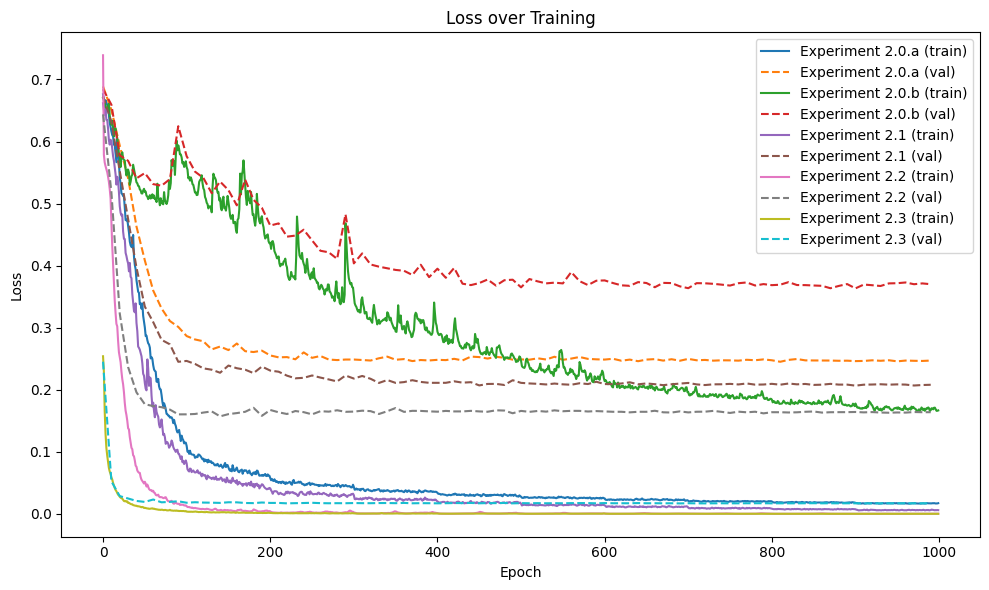

In [44]:
fig, ax = plt.subplots(figsize=(10, 6))
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "loss_all/train")
    ax.plot(steps, values, label=f"{label} (train)")
    steps, values = get_scalar_series(ea, "loss_all/val")
    ax.plot(steps, values, linestyle="--", label=f"{label} (val)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.set_title("Loss over Training")
ax.legend()
plt.tight_layout()
plt.show()

## Angular Error Curves

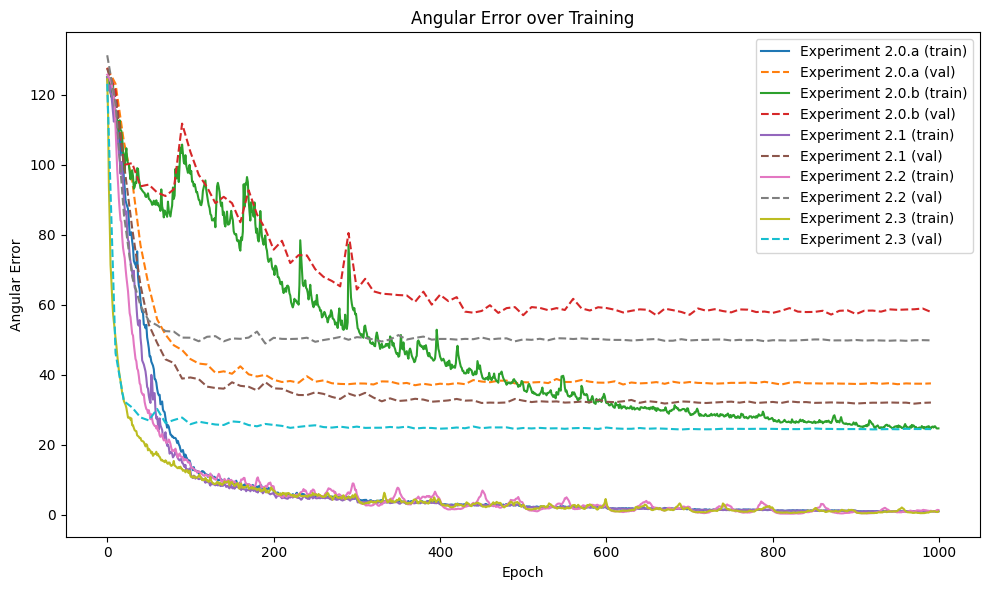

In [45]:
fig, ax = plt.subplots(figsize=(10, 6))
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "angular_error/train")
    ax.plot(steps, values, label=f"{label} (train)")
    steps, values = get_scalar_series(ea, "angular_error/val")
    ax.plot(steps, values, linestyle="--", label=f"{label} (val)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Angular Error")
ax.set_title("Angular Error over Training")
ax.legend()
plt.tight_layout()
plt.show()

## Angular Error (Training vs Validation Side-by-Side)

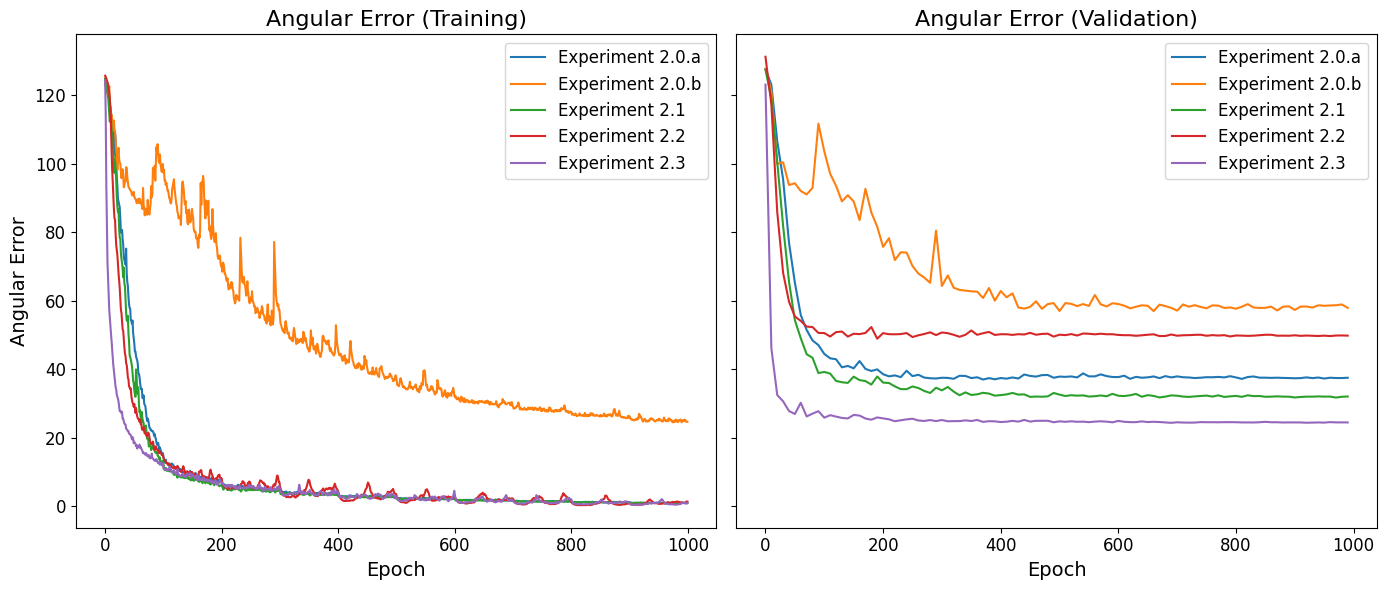

In [47]:
# Define consistent colors for each experiment
exp_colors = {exp_name: plt.cm.tab10(i) for i, exp_name in enumerate(data.keys())}

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Training plot (left)
ax_train = axes[0]
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "angular_error/train")
    ax_train.plot(steps, values, label=label, color=exp_colors[exp_name])
ax_train.set_xlabel("Epoch", fontsize=14)
ax_train.set_ylabel("Angular Error", fontsize=14)
ax_train.set_title("Angular Error (Training)", fontsize=16)
ax_train.legend(fontsize=12)
ax_train.tick_params(axis='both', labelsize=12)

# Validation plot (right)
ax_val = axes[1]
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "angular_error/val")
    ax_val.plot(steps, values, label=label, color=exp_colors[exp_name])
ax_val.set_xlabel("Epoch", fontsize=14)
ax_val.set_title("Angular Error (Validation)", fontsize=16)
ax_val.legend(fontsize=12)
ax_val.tick_params(axis='both', labelsize=12)

plt.tight_layout()
plt.show()

## Angular Error (Training Only)

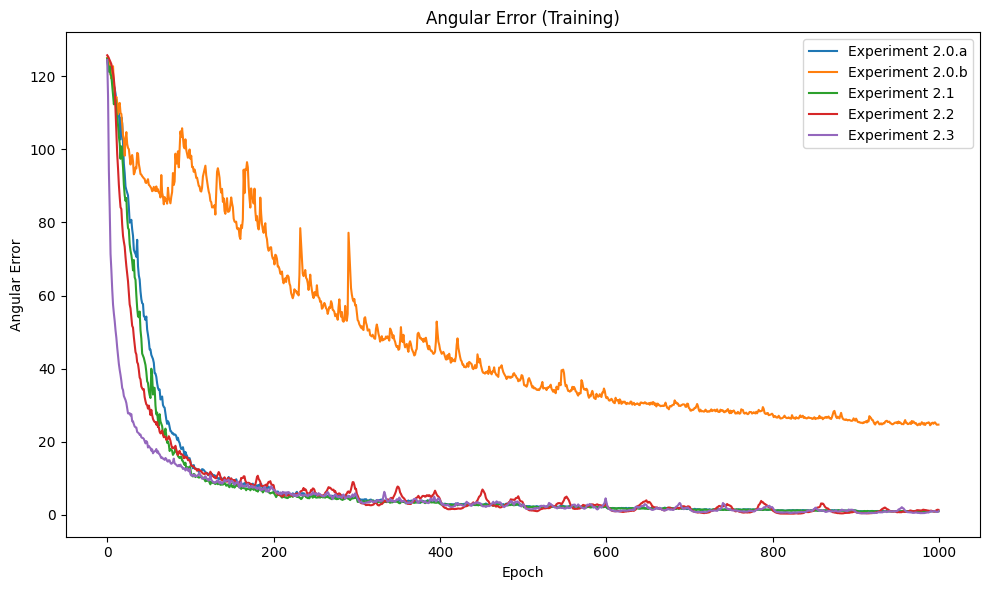

In [48]:
fig, ax = plt.subplots(figsize=(10, 6))
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "angular_error/train")
    ax.plot(steps, values, label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Angular Error")
ax.set_title("Angular Error (Training)")
ax.legend()
plt.tight_layout()
plt.show()

## Angular Error (Validation Only)

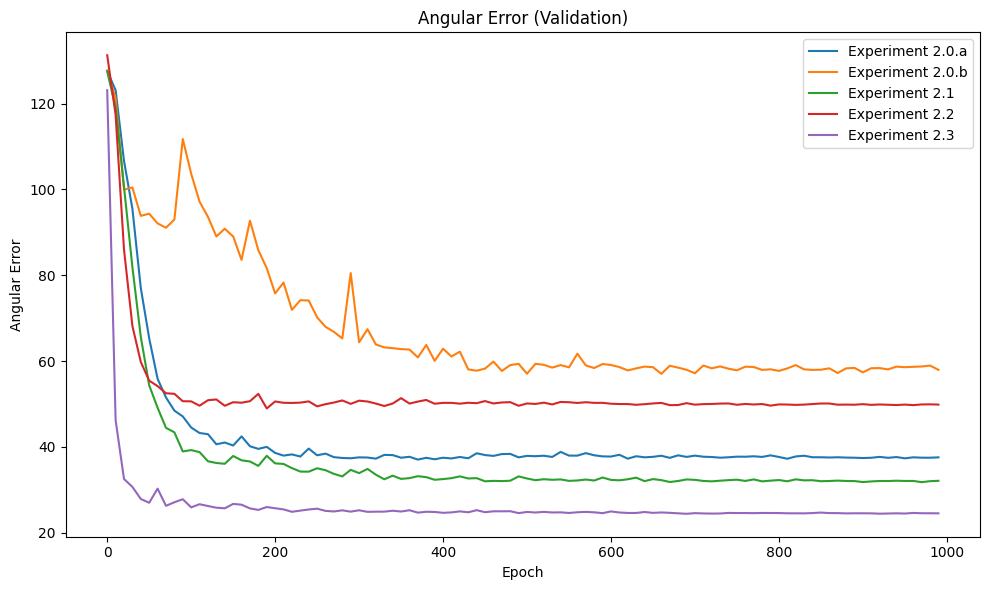

In [49]:
fig, ax = plt.subplots(figsize=(10, 6))
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    label = exp_data["label"]
    steps, values = get_scalar_series(ea, "angular_error/val")
    ax.plot(steps, values, label=label)
ax.set_xlabel("Epoch")
ax.set_ylabel("Angular Error")
ax.set_title("Angular Error (Validation)")
ax.legend()
plt.tight_layout()
plt.show()

## Final Test Angular Error (Bar Plot)

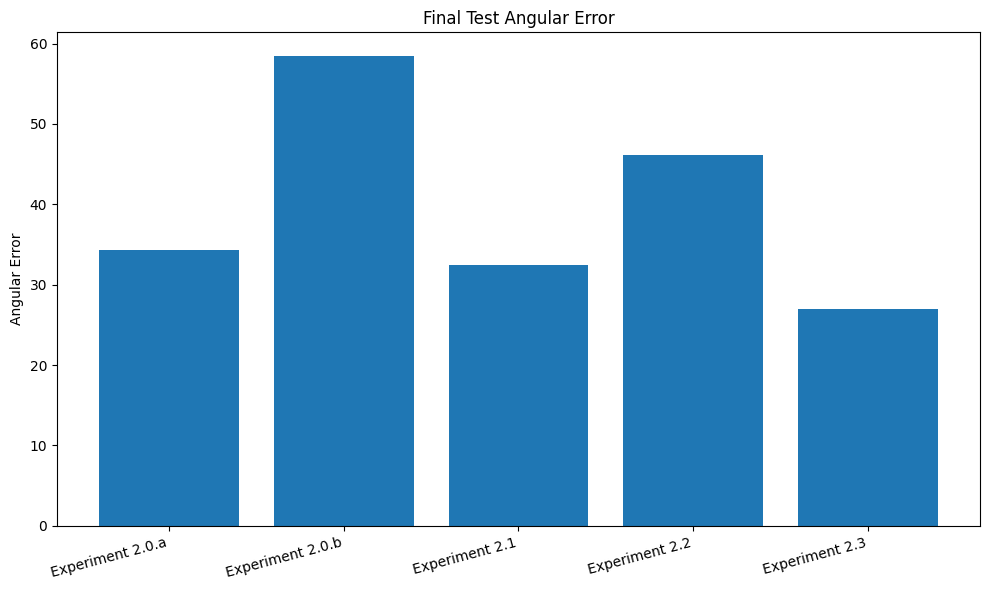

In [50]:
labels = []
test_errors = []
for exp_name, exp_data in data.items():
    ea = exp_data["ea"]
    labels.append(exp_data["label"])
    test_errors.append(get_final_scalar(ea, "angular_error/test"))

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(labels, test_errors)
ax.set_ylabel("Angular Error")
ax.set_title("Final Test Angular Error")
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.show()